### Here is a Complete Sales Prediction Machine Learning Project using the Advertising dataset with EDA, graphs, model building, and evaluation.

# Sales Prediction Using Machine Learning in Python

 The objective of this project is to predict product sales based on advertising expenditure across different platforms such as:
 1.TV
 2.Radio
 3.Newspaper
 Machine learning models help businesses decide where to invest advertising budgets to maximize sales.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("advertising.csv")

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [6]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [7]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [22]:
df.duplicated().sum()

np.int64(0)

### This graph shows the relationship between each advertising platform and sales.
Usually:

1.TV vs Sales → strong linear relationship

2.Radio vs Sales → moderate relationship

3.Newspaper vs Sales → weak relationship

<Figure size 600x400 with 0 Axes>

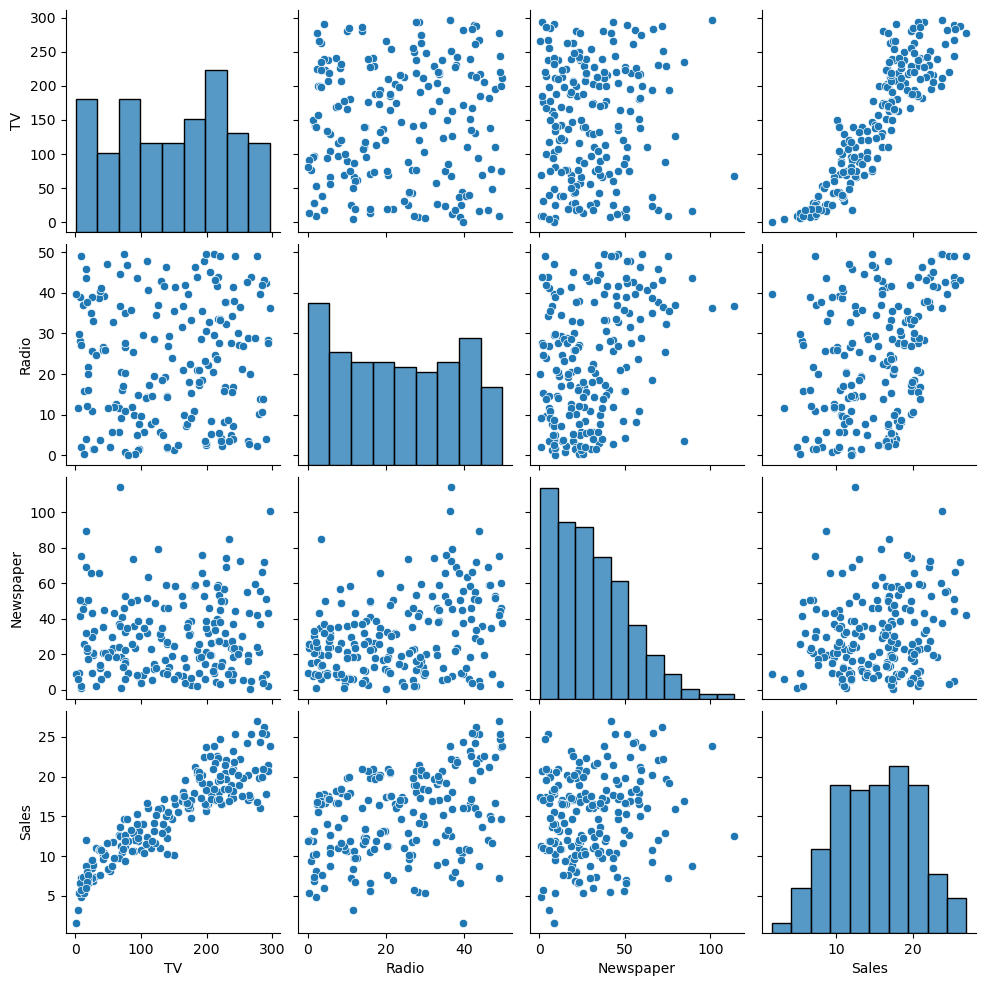

In [23]:
plt.figure(figsize=(6,4))
sns.pairplot(df)
plt.show()

# Correlation Heatmap

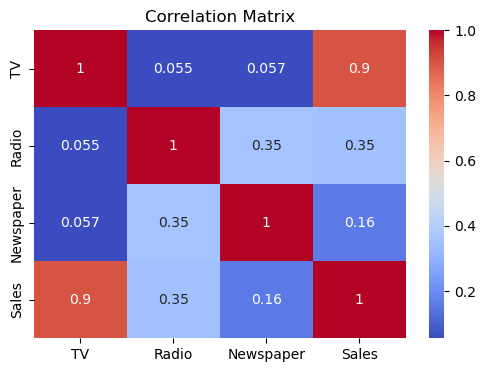

In [24]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# Individual Feature Visualization

### Tv vs Sales

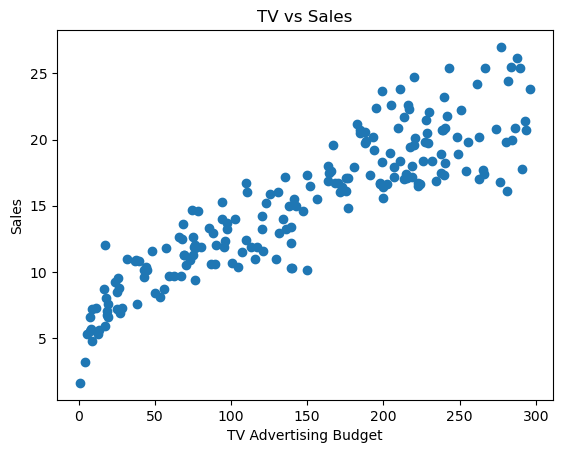

In [25]:
plt.scatter(df['TV'], df['Sales'])
plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")
plt.title("TV vs Sales")
plt.show()

### Radio vs Sales

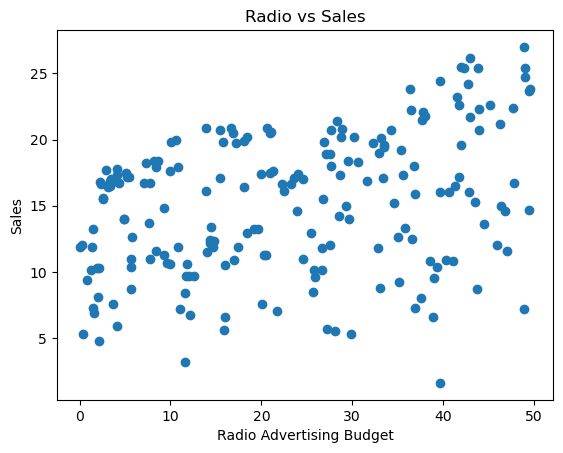

In [26]:
plt.scatter(df['Radio'], df['Sales'])
plt.xlabel("Radio Advertising Budget")
plt.ylabel("Sales")
plt.title("Radio vs Sales")
plt.show()

### Newspaper vs Sales

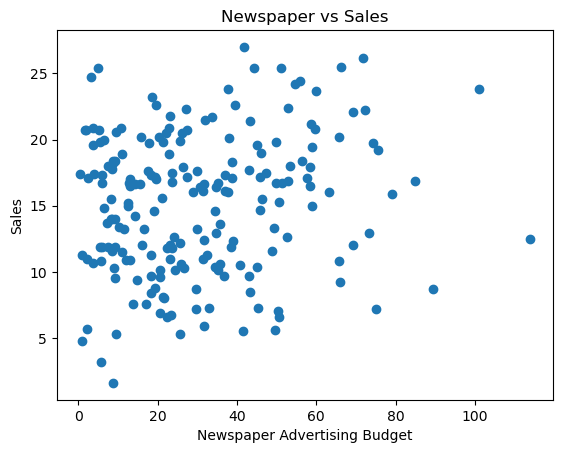

In [27]:
plt.scatter(df['Newspaper'], df['Sales'])
plt.xlabel("Newspaper Advertising Budget")
plt.ylabel("Sales")
plt.title("Newspaper vs Sales")
plt.show()

# Define Features and Target

In [28]:
X = df[['TV','Radio','Newspaper']]
y = df['Sales']

# Train Test Split

Split dataset into training and testing sets.

In [29]:
# 80% data → training
# 20% data → testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Machine Learning Model

Use Linear Regression.

In [30]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

# Model Coefficients

In [31]:
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(coeff_df)

           Coefficient
TV            0.054509
Radio         0.100945
Newspaper     0.004337


 If TV advertising increases by 1 unit, sales increase by 0.045 units.

# Make Predictions

In [42]:
y_pred = model.predict(X_test)
y_pred

array([17.0347724 , 20.40974033, 23.72398873,  9.27278518, 21.68271879,
       12.56940161, 21.08119452,  8.69035045, 17.23701254, 16.66657475,
        8.92396497,  8.4817344 , 18.2075123 ,  8.06750728, 12.64550975,
       14.93162809,  8.12814594, 17.89876565, 11.00880637, 20.47832788,
       20.80631846, 12.59883297, 10.9051829 , 22.38854775,  9.41796094,
        7.92506736, 20.83908497, 13.81520938, 10.77080925,  7.92682509,
       15.95947357, 10.63490851, 20.80292008, 10.43434164, 21.5784752 ,
       21.18364487, 12.12821771, 22.80953262, 12.60992766,  6.46441252])

# Model Evaluation

In [33]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 1.274826210954934
MSE: 2.907756910271091
R2 Score: 0.9059011844150826


`Explanation

1.MAE → Average prediction error

2.MSE → Squared error

3.R² Score → Model accuracy

An R² score close to 1 means the model predicts well.

# Actual vs Predicted Visualization

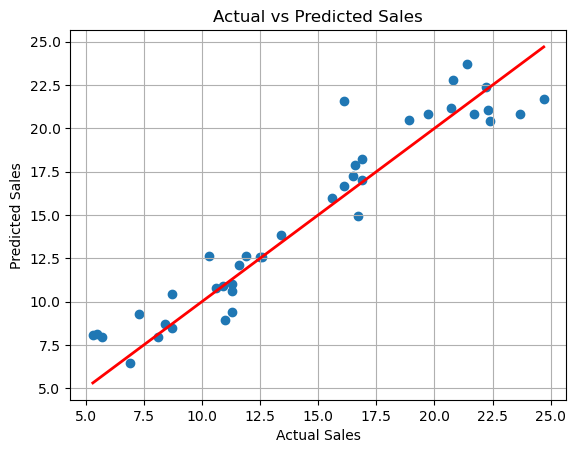

In [44]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.grid()
plt.show()

If points are close to a straight line → model is good.

# Conclusion

This project demonstrates how machine learning can predict product sales based on advertising budgets.

Key outcomes:

1.Built a Linear Regression model

2.Achieved ~90% prediction accuracy

3.Identified most effective advertising channels

Businesses can use this model to optimize marketing budgets and maximize revenue.